In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(X_train, _), (_, _) = mnist.load_data()

print("Dataset shape:", X_train.shape)

Dataset shape: (60000, 28, 28)


In [3]:
# Normalize pixel values from [0, 255] to [-1, 1]
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)

print("Preprocessed dataset shape:", X_train.shape)
print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())

Preprocessed dataset shape: (60000, 28, 28, 1)
Minimum value: -1.0
Maximum value: 1.0


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape

def build_generator():
    model = Sequential()

    model.add(Dense(128, input_dim=100))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28, 28, 1)))

    return model

generator = build_generator()

print("Generator Summary:")
generator.summary()

C:\Users\Ajith Prasad Shetty\miniconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generator Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import Adam

def build_discriminator():
    model = Sequential()

    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(128))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        metrics=['accuracy']
    )

    return model

discriminator = build_discriminator()

print("Discriminator Summary:")
discriminator.summary()

Discriminator Summary:


C:\Users\Ajith Prasad Shetty\miniconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.layers import Input

# Freeze discriminator while training the generator
discriminator.trainable = False

# Build GAN
gan = Sequential([
    Input(shape=(100,)),
    generator,
    discriminator
])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5)
)

print("GAN Model Summary:")
gan.summary()

GAN Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 28, 28, 1)           │         114,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 1)                   │         100,609 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 214,673 (838.57 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 100,609 (393.00 KB)

In [7]:
import matplotlib.pyplot as plt

# Training settings
epochs = 1000
batch_size = 64

# Labels
real_label = np.ones((batch_size, 1))
fake_label = np.zeros((batch_size, 1))

for epoch in range(epochs):

    # -------------------------
    # Train Discriminator
    # -------------------------

    # Select random real images
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]

    # Generate fake images
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    # Train discriminator
    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(
        real_images, real_label
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images, fake_label
    )

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # -------------------------
    # Train Generator
    # -------------------------

    noise = np.random.normal(0, 1, (batch_size, 100))

    discriminator.trainable = False

    g_loss = gan.train_on_batch(
        noise, real_label
    )

    # Display progress
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}/{epochs} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Accuracy: {d_loss[1]*100:.2f}% | "
            f"G Loss: {float(g_loss):.4f}"
        )

Epoch 0/1000 | D Loss: 0.7906 | D Accuracy: 32.81% | G Loss: 0.5930
Epoch 100/1000 | D Loss: 0.3899 | D Accuracy: 70.31% | G Loss: 0.7247
Epoch 200/1000 | D Loss: 0.3891 | D Accuracy: 79.69% | G Loss: 0.8484
Epoch 300/1000 | D Loss: 0.4296 | D Accuracy: 78.12% | G Loss: 0.8383
Epoch 400/1000 | D Loss: 0.5371 | D Accuracy: 65.62% | G Loss: 0.8222
Epoch 500/1000 | D Loss: 0.6260 | D Accuracy: 53.12% | G Loss: 0.8301
Epoch 600/1000 | D Loss: 0.6108 | D Accuracy: 64.06% | G Loss: 0.8574
Epoch 700/1000 | D Loss: 0.6373 | D Accuracy: 54.69% | G Loss: 0.8196
Epoch 800/1000 | D Loss: 0.6569 | D Accuracy: 53.12% | G Loss: 0.8064
Epoch 900/1000 | D Loss: 0.6281 | D Accuracy: 57.03% | G Loss: 0.9641


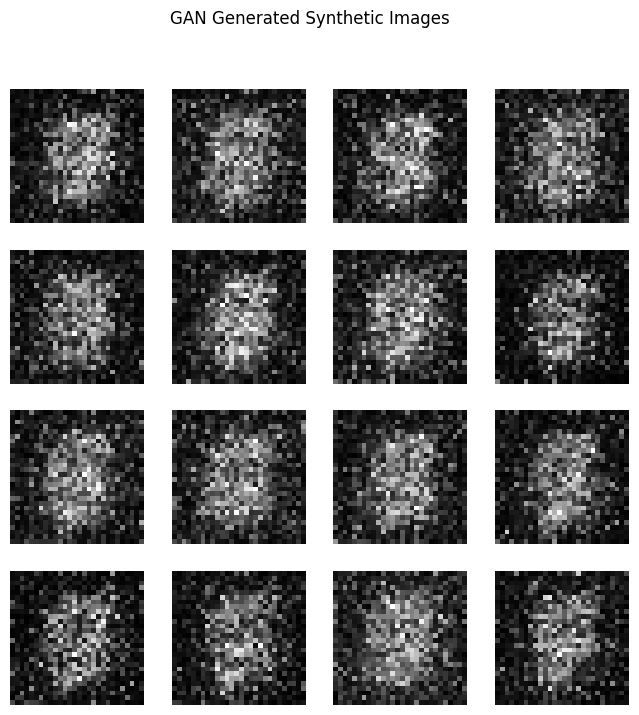

In [8]:
# Generate final synthetic images

noise = np.random.normal(0, 1, (16, 100))

generated_images = generator.predict(noise, verbose=0)

# Convert from [-1, 1] to [0, 1]
generated_images = (generated_images + 1) / 2

# Display images
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("GAN Generated Synthetic Images")
plt.show()